In [171]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [172]:
try:
    df=pd.read_csv(r'winequality-white.csv',sep=';')
    print('Dataset Loaded Succesfully')
except:
    print('Dataset Not Found')

Dataset Loaded Succesfully


In [173]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [174]:
df.columns = df.columns.str.replace(" ", "_")


In [175]:
df

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [176]:
df.isnull().sum().sort_values(ascending=False)

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [177]:
px.histogram(df,x='fixed_acidity',nbins=125,color='quality')

In [178]:
px.violin(df,x='volatile_acidity')

In [179]:

px.box(df,x='sulphates')

In [180]:
px.area(df,x='fixed_acidity')

In [181]:
X=df.drop('quality',axis=1)
y=df['quality']
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [182]:
X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


In [183]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer,make_column_selector as selector
from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer

num=Pipeline([
    ('scaler',RobustScaler()),
])
preprocessor=ColumnTransformer([
    ('nums',num,selector(dtype_include=np.number))
])
preprocessor

,transformers,"[('nums', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"


In [184]:
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
model=Pipeline([
    ('preprocessing',preprocessor),
    ('model',XGBClassifier())

])
model

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('nums', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [185]:
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
param_grid={
    'model__n_estimators':[100,200,500,1000],
    'model__max_depth':[3,5,10],
    'model__learning_rate':[0.3]

}

cv=GridSearchCV(
    param_grid=param_grid,
    estimator=model,
    cv=15,
    n_jobs=3,
    verbose=1,
    scoring='f1_score',
    error_score='raise'
)

model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [186]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,confusion_matrix,classification_report
print('Accuracy',accuracy_score(y_test,y_pred))
print('Precision Score',precision_score(y_test,y_pred,average='macro'))
print('f1 score',f1_score(y_test,y_pred,average='macro'))
print('confusion matrix',confusion_matrix(y_test,y_pred))
print('classification report',classification_report(y_test,y_pred))


Accuracy 0.6795918367346939
Precision Score 0.5396682791593278
f1 score 0.4992556280233875
confusion matrix [[  0   0   4   1   0   0]
 [  0   9  10   6   0   0]
 [  0   6 203  80   2   0]
 [  0   1  67 330  30   4]
 [  0   0   6  71 108   7]
 [  0   0   1   8  10  16]]
classification report               precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.56      0.36      0.44        25
           2       0.70      0.70      0.70       291
           3       0.67      0.76      0.71       432
           4       0.72      0.56      0.63       192
           5       0.59      0.46      0.52        35

    accuracy                           0.68       980
   macro avg       0.54      0.47      0.50       980
weighted avg       0.68      0.68      0.67       980



Text(0.5, 1.0, 'Heatmap Of Confusion Matrix')

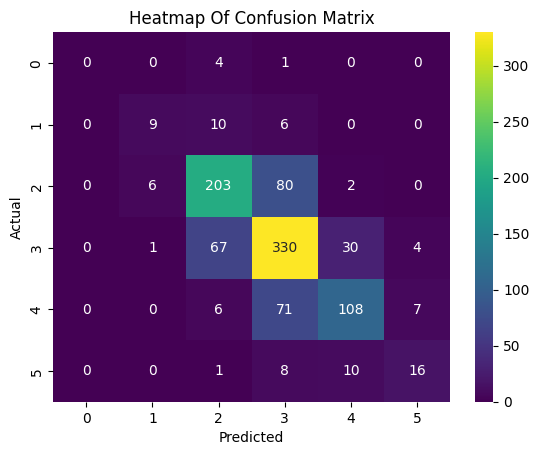

In [197]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='viridis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Heatmap Of Confusion Matrix')